# 1 · Causality — *Can we trust the number?*

> **Chapter 1 of the Aurora story.** The dashboard says fund Search. Before Aurora moves a dollar, the
> data-science team asks the causal question: *what would have to be true for "Search ROAS" to mean
> what we think it means?* This notebook draws the causal map, finds what to adjust for, shows why
> adjustment **alone isn't enough**, and anchors the model to a **randomized experiment**.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
from loguru import logger
logger.remove(); logger.add(sys.stderr, level="ERROR")   # quiet framework logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aurora import generate_aurora, CHANNELS, PRODUCTS, PALETTE, CHANNEL_COLORS

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.2),
    "axes.grid": True, "grid.alpha": 0.18,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfc7bd", "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "font.size": 10,
})
ACCENT, INK, MUTED = PALETTE["accent"], PALETTE["ink"], PALETTE["muted"]

aurora = generate_aurora()      # the one dataset every chapter shares
import networkx as nx
from matplotlib.patches import Patch

## Step 1 — Draw the causal map (a DAG)

Causal claims need assumptions, and assumptions should be *explicit*. `mmm_framework` lets you state
them as a directed acyclic graph. Here is Aurora's: **Demand** confounds spend↔sales, **Awareness** sits
on the path from TV to Sales (a *mediator*), and **Price** is a clean predictor. *(For legibility the
map shows two representative channels — TV the brand-builder and Search the demand-chaser; the fitted
model in Steps 5–6 uses all four.)*

In [2]:
from mmm_framework.dag_model_builder.dag_spec import DAGSpec, DAGNode, DAGEdge, NodeType

dag = DAGSpec(
    nodes=[
        DAGNode(id="sales",  variable_name="Sales",     node_type=NodeType.KPI),
        DAGNode(id="tv",     variable_name="TV",        node_type=NodeType.MEDIA),
        DAGNode(id="search", variable_name="Search",    node_type=NodeType.MEDIA),
        DAGNode(id="demand", variable_name="Demand",    node_type=NodeType.CONTROL),
        DAGNode(id="price",  variable_name="Price",     node_type=NodeType.CONTROL),
        DAGNode(id="aware",  variable_name="Awareness", node_type=NodeType.CONTROL),
    ],
    edges=[
        DAGEdge(source="tv", target="sales"), DAGEdge(source="search", target="sales"),
        DAGEdge(source="demand", target="search"), DAGEdge(source="demand", target="sales"),
        DAGEdge(source="price", target="sales"),
        DAGEdge(source="tv", target="aware"), DAGEdge(source="aware", target="sales"),
    ],
)
print("media:", [n.variable_name for n in dag.media_nodes],
      "| controls:", [n.variable_name for n in dag.control_nodes])

media: ['TV', 'Search'] | controls: ['Demand', 'Price', 'Awareness']


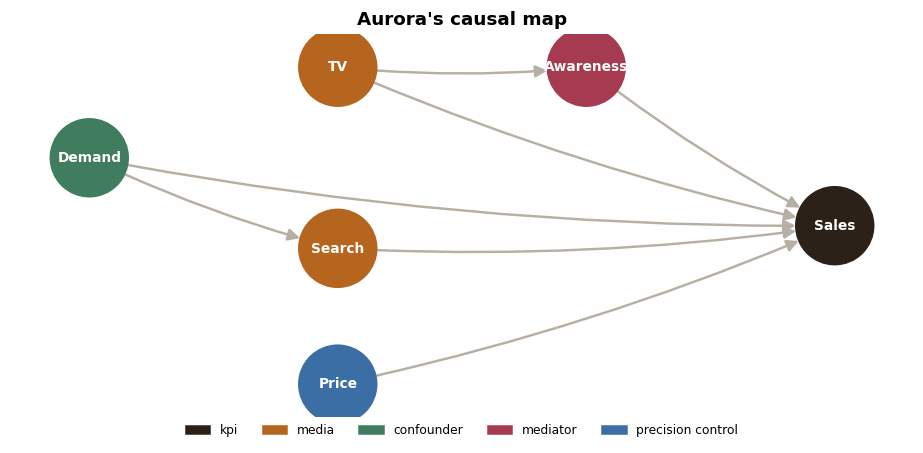

In [3]:
# Draw it, coloured by causal role (computed in Step 3).
ROLE_COLORS = {"kpi": INK, "media": ACCENT, "confounder": PALETTE["leaf"],
               "mediator": PALETTE["berry"], "precision_control": PALETTE["sky"]}
G = nx.DiGraph(); G.add_edges_from((e.source, e.target) for e in dag.edges)
pos = {"demand": (0, 1.2), "tv": (1, 2), "search": (1, 0.4), "aware": (2, 2),
       "price": (1, -0.8), "sales": (3, 0.6)}
role = {"sales": "kpi", "tv": "media", "search": "media", "demand": "confounder",
        "aware": "mediator", "price": "precision_control"}
plt.figure(figsize=(8.5, 4.2))
nx.draw_networkx_edges(G, pos, arrowsize=16, edge_color="#b8afa4", width=1.6,
                       connectionstyle="arc3,rad=0.05", node_size=2600)
nx.draw_networkx_nodes(G, pos, node_size=2600,
                       node_color=[ROLE_COLORS[role[n]] for n in G.nodes])
nx.draw_networkx_labels(G, pos, {n: dag.get_node(n).variable_name for n in G.nodes},
                        font_color="white", font_size=9, font_weight="bold")
plt.legend(handles=[Patch(color=v, label=k.replace("_"," ")) for k, v in ROLE_COLORS.items()],
           loc="lower center", ncol=5, fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.08))
plt.title("Aurora's causal map"); plt.axis("off"); plt.tight_layout(); plt.show()

## Step 2 — Identify the effect: *what must we adjust for?*

Given the graph, `identification_report` finds the **back-door adjustment set** — the variables you must
condition on to read TV's (or Search's) effect cleanly — and flags variables you must **not** touch.

In [4]:
from mmm_framework.dag_model_builder.identification import identification_report

rep = identification_report(dag, treatment_id="search", outcome_id="sales")
print("Adjustment set (condition on these):", rep.adjustment_set)
print("Descendants of Search (must NOT adjust):", rep.descendants_of_treatment)
print("Effect identifiable?", rep.identifiable)
print("\nBack-door paths found:")
for p in rep.backdoor_paths:
    print("  ", p.render(), " — blocked by:", p.blocked_by or "(open!)")

Adjustment set (condition on these): ['demand']
Descendants of Search (must NOT adjust): ['sales']
Effect identifiable? True

Back-door paths found:
   search ← demand → sales  — blocked by: ['demand']


The model must **condition on Demand** (to close the `Search ← Demand → Sales` back-door) and must
**never condition on Awareness** for a *total* TV effect — Awareness is on the causal path, so adjusting
it would throw away exactly the effect we want to measure (the classic *"bad control"*).

## Step 3 — Auto-detect bad controls (so non-experts can't shoot themselves in the foot)

`classify_dag_roles` labels every candidate control. The framework will later **refuse** to condition on
a mediator or collider.

In [5]:
from mmm_framework.dag_model_builder.identification import classify_dag_roles

cls = classify_dag_roles(dag, treatment_ids=["tv", "search"], outcome_id="sales",
                         control_ids=["demand", "price", "aware"])
rows = []
for cid in ["demand", "price", "aware"]:
    r, why = cls.role_for(cid)
    rows.append({"variable": dag.get_node(cid).variable_name, "role": r,
                 "use it?": "✅ keep" if r in ("confounder", "precision_control") else "⛔ REMOVE",
                 "why": why[:80] + "…"})
pd.DataFrame(rows)

,variable,role,use it?,why
0,Demand,confounder,✅ keep,it is a common cause of media and the KPI (bac...
1,Price,precision_control,✅ keep,"it predicts the KPI but is not a common cause,..."
2,Awareness,mediator,⛔ REMOVE,it is a consequence of media 'tv' (post-treatm...


## Step 4 — The framework enforces it

`dag_to_mff_config` turns the graph into a model configuration, tagging each control with its causal
role. When you build a model that conditions on a mediator, it **raises** — the bad control never makes
it into the likelihood.

In [6]:
from mmm_framework.dag_model_builder.config_translator import dag_to_mff_config

cfg = dag_to_mff_config(dag)
for ctrl in cfg.controls:
    print(f"  {ctrl.name:10s} -> {getattr(ctrl, 'causal_role', None)}")

  Demand     -> CausalControlRole.CONFOUNDER
  Price      -> CausalControlRole.PRECISION_CONTROL
  Awareness  -> CausalControlRole.MEDIATOR


## Step 5 — Why adjustment *alone* isn't enough

Here's the uncomfortable truth most MMM decks skip. Let's fit Aurora's model two ways — **blind to
demand** vs. **controlling for demand** — and compare the recovered ROI to the truth.

*(Small draws for speed; `cores=1` keeps macOS sampling crash-free.)*

In [7]:
from mmm_framework import BayesianMMM, ModelConfigBuilder, SeasonalityConfigBuilder, TrendConfig, TrendType
from mmm_framework.analysis import MMMAnalyzer

def base_config():
    return (ModelConfigBuilder().bayesian_pymc().with_chains(2).with_draws(400).with_tune(400)
            .with_seasonality_builder(SeasonalityConfigBuilder().with_yearly(order=2)).build())

def fit_and_roi(control_demand):
    panel = aurora.base_panel(control_demand=control_demand)
    m = BayesianMMM(panel, base_config(), TrendConfig(type=TrendType.LINEAR))
    m.fit(draws=400, tune=400, chains=2, cores=1, random_seed=0)
    return m, MMMAnalyzer(m).compute_channel_roi().set_index("Channel")["ROI"]

m_blind, roi_blind = fit_and_roi(control_demand=False)
m_ctrl,  roi_ctrl  = fit_and_roi(control_demand=True)

Sampling: [adstock_Display, adstock_Search, adstock_Social, adstock_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


Initializing NUTS using adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, trend_slope, season_yearly, adstock_TV, sat_lam_TV, beta_TV, adstock_Search, sat_lam_Search, beta_Search, adstock_Social, sat_lam_Social, beta_Social, adstock_Display, sat_lam_Display, beta_Display, beta_controls, sigma]


Output()

...

Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

,true ROAS,demand-blind,demand-controlled
TV,2.14,0.12,0.22
Search,0.66,5.70,2.82
Social,0.49,0.69,0.90
Display,2.11,0.29,0.45


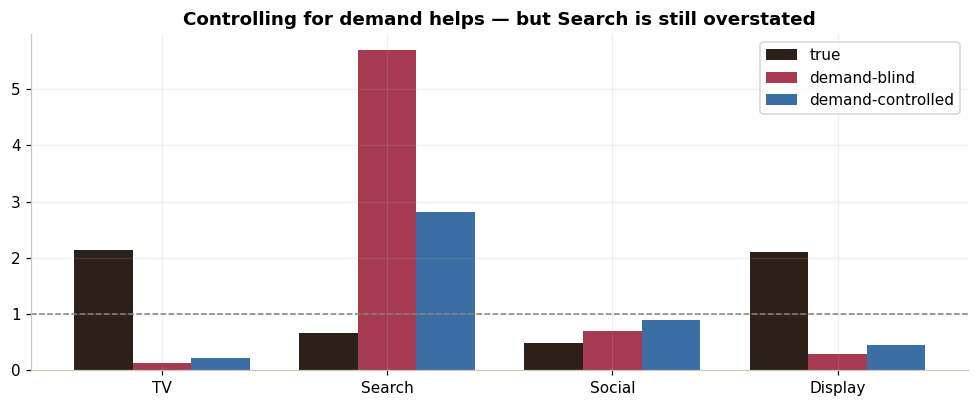

In [8]:
comp = pd.DataFrame({"true ROAS": aurora.true_roas,
                     "demand-blind": roi_blind, "demand-controlled": roi_ctrl}).loc[CHANNELS]
display(comp.round(2))

x = np.arange(len(CHANNELS)); w = 0.26
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(x-w, comp["true ROAS"], w, label="true", color=INK)
ax.bar(x,   comp["demand-blind"], w, label="demand-blind", color=PALETTE["berry"])
ax.bar(x+w, comp["demand-controlled"], w, label="demand-controlled", color=PALETTE["sky"])
ax.set_xticks(x); ax.set_xticklabels(CHANNELS); ax.axhline(1, color=MUTED, ls="--", lw=1)
ax.set_title("Controlling for demand helps — but Search is still overstated"); ax.legend()
plt.tight_layout(); plt.show()

Subtract the truth from each estimate and the **leftover bias** is easier to read: controlling for
demand shrinks every bar, but Search's stays stubbornly positive.

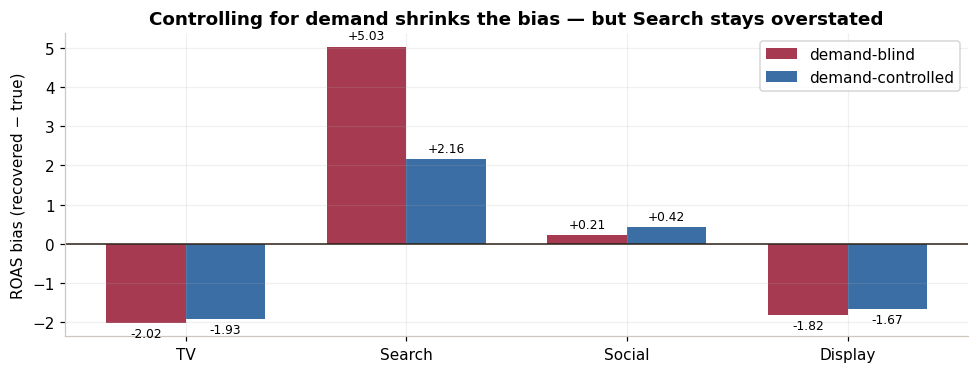

In [9]:
# Bias = recovered - true. Controlling for demand shrinks it, but doesn't kill it.
chs = list(CHANNELS)
bias_blind = (comp["demand-blind"] - comp["true ROAS"]).loc[chs]
bias_ctrl  = (comp["demand-controlled"] - comp["true ROAS"]).loc[chs]
x = np.arange(len(chs)); w = 0.36
fig, ax = plt.subplots(figsize=(9, 3.5))
b1 = ax.bar(x - w/2, bias_blind, w, label="demand-blind",       color=PALETTE["berry"])
b2 = ax.bar(x + w/2, bias_ctrl,  w, label="demand-controlled",  color=PALETTE["sky"])
ax.axhline(0, color=INK, lw=1)
ax.set_xticks(x); ax.set_xticklabels(chs)
ax.set_ylabel("ROAS bias (recovered − true)")
ax.set_title("Controlling for demand shrinks the bias — but Search stays overstated")
ax.bar_label(b1, fmt="%+.2f", padding=3, fontsize=8)
ax.bar_label(b2, fmt="%+.2f", padding=3, fontsize=8)
ax.legend()
plt.tight_layout(); plt.show()

Controlling for demand pulls Search's ROI down — but it's **still far above its true 0.66**. The demand
proxy is collinear with demand-chasing spend, and no observational adjustment fully removes that. *This
is the central limitation of any observational MMM*, and the framework says so out loud. The fix isn't
more controls. It's **randomized evidence**.

## Step 6 — Anchor to an experiment

Last quarter Aurora ran a **geo lift test** on Search and Social and measured their true incremental
ROAS. `mmm_framework` folds that straight into the likelihood: the experiment becomes a data point the
model must agree with — updating the coefficient, the saturation curve, **and** the adstock jointly.

In [10]:
from mmm_framework.calibration import ExperimentMeasurement, ExperimentEstimand

window = (str(aurora.weeks[0].date()), str(aurora.weeks[-1].date()))
experiments = [
    ExperimentMeasurement("Search", window, value=float(aurora.true_roas["Search"]), se=0.07,
                          estimand=ExperimentEstimand.ROAS),
    ExperimentMeasurement("Social", window, value=float(aurora.true_roas["Social"]), se=0.07,
                          estimand=ExperimentEstimand.ROAS),
]
panel = aurora.base_panel(control_demand=True)
m_cal = BayesianMMM(panel, base_config(), TrendConfig(type=TrendType.LINEAR), experiments=experiments)
m_cal.fit(draws=400, tune=400, chains=2, cores=1, random_seed=0)
roi_cal = MMMAnalyzer(m_cal).compute_channel_roi().set_index("Channel")["ROI"]

Sampling: [adstock_Display, adstock_Search, adstock_Social, adstock_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, experiment_Search_roas_0, experiment_Social_roas_1, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


Initializing NUTS using adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, trend_slope, season_yearly, adstock_TV, sat_lam_TV, beta_TV, adstock_Search, sat_lam_Search, beta_Search, adstock_Social, sat_lam_Social, beta_Social, adstock_Display, sat_lam_Display, beta_Display, beta_controls, sigma]


Output()

...

Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

In [11]:
final = pd.DataFrame({"true ROAS": aurora.true_roas, "observational": roi_ctrl,
                      "experiment-calibrated": roi_cal}).loc[CHANNELS]
display(final.round(2))
for ch in ["Search", "Social"]:
    print(f"{ch}: observational {roi_ctrl[ch]:.2f}  →  calibrated {roi_cal[ch]:.2f}   (true {aurora.true_roas[ch]:.2f})")

,true ROAS,observational,experiment-calibrated
TV,2.14,0.22,0.68
Search,0.66,2.82,0.68
Social,0.49,0.90,0.50
Display,2.11,0.45,1.64


Search: observational 2.82  →  calibrated 0.68   (true 0.66)
Social: observational 0.90  →  calibrated 0.50   (true 0.49)


The whole chapter in one picture: each calibrated channel's ROAS **slides off its inflated observational
value onto the truth** (the `|` mark) once the experiment enters the likelihood.

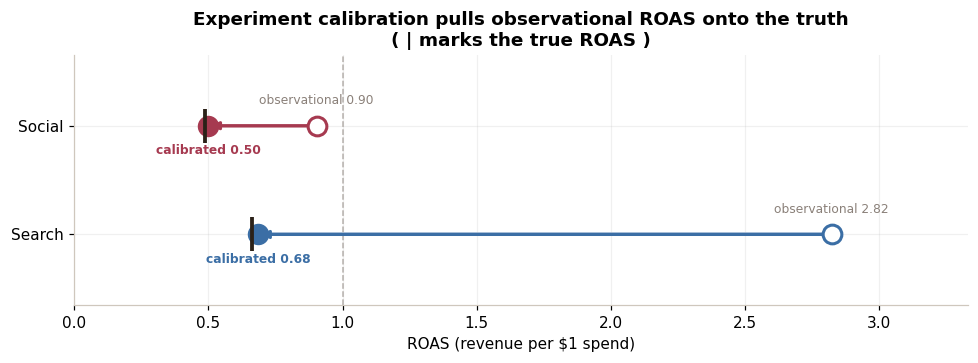

In [12]:
# The calibration result, drawn: each channel's observational ROAS slides onto its truth.
calib = ["Search", "Social"]                       # the channels the experiment anchored
fig, ax = plt.subplots(figsize=(9, 3.4))
for i, ch in enumerate(calib):
    obs, cal, tru = roi_ctrl[ch], roi_cal[ch], aurora.true_roas[ch]
    ax.plot([obs, cal], [i, i], color=CHANNEL_COLORS[ch], lw=2.5, alpha=.45, zorder=1)
    ax.annotate("", xy=(cal, i), xytext=(obs, i),
                arrowprops=dict(arrowstyle="-|>", color=CHANNEL_COLORS[ch], lw=2))
    ax.scatter(obs, i, s=150, color="white", edgecolor=CHANNEL_COLORS[ch], lw=2, zorder=3)
    ax.scatter(cal, i, s=170, color=CHANNEL_COLORS[ch], zorder=3)
    ax.scatter(tru, i, marker="|", s=520, color=INK, lw=2.5, zorder=4)
    ax.text(obs, i + 0.20, f"observational {obs:.2f}", ha="center", fontsize=8, color=MUTED)
    ax.text(cal, i - 0.26, f"calibrated {cal:.2f}", ha="center", fontsize=8,
            weight="bold", color=CHANNEL_COLORS[ch])
ax.axvline(1.0, color=MUTED, ls="--", lw=1, alpha=.6)
ax.set_yticks(range(len(calib))); ax.set_yticklabels(calib)
ax.set_ylim(-0.65, len(calib) - 0.35)
ax.set_xlim(0, max(float(roi_ctrl[calib].max()), 1.2) * 1.18)
ax.set_xlabel("ROAS (revenue per $1 spend)")
ax.set_title("Experiment calibration pulls observational ROAS onto the truth\n( | marks the true ROAS )")
plt.tight_layout(); plt.show()

**There it is.** The experiment pulls Search and Social down onto their true ROAS — the demand mirage is
gone. This is the single most important move in causal MMM: *anchor the observational model to
randomized evidence.*

### Takeaways
- A DAG makes assumptions explicit and **auto-detects bad controls** (Awareness is a mediator — never a control).
- **Observational adjustment helps but is not sufficient** when spend chases demand.
- **Experiment calibration** corrects the residual bias — Search/Social snap to truth.

But notice TV is *still* low. The base model can't see that TV works through **awareness** — that's
**`03_extended_mmm.ipynb`**. First, let's read the base model properly: **`02_base_mmm.ipynb`**.